# Ouvidoria Inteligente · Entrega 2
## Encontrando a mesma reclamação escrita de outro jeito

Cerca de 15% das manifestações repetem um problema já relatado. O objetivo é a função `detectar_duplicatas(textos, limiar=0.85)`, a escolha justificada do limiar e a análise dos erros contra o gabarito em `data/duplicatas_gabarito.json`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nucleo_ouvidoria as nucleo

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 110)

base = nucleo.carregar_manifestacoes()
pos = {m: i for i, m in enumerate(base["id"])}
base.groupby("categoria_oficial").size().rename("manifestações").to_frame()

,manifestações
categoria_oficial,
educação,8
infraestrutura,9
meio ambiente,8
saúde,8
segurança,7


### 1 · A função
A implementação fica em `nucleo_ouvidoria.py`, porque o app também a usa. O código dela:

In [2]:
import inspect
from nucleo_ouvidoria import detectar_duplicatas
print(inspect.getsource(detectar_duplicatas))

def detectar_duplicatas(textos, limiar: float = 0.85, vetorizador: Vetorizador | None = None,
                        ids=None) -> list[tuple]:
    """Todos os pares (id_a, id_b, cosseno) com similaridade >= limiar, do mais parecido ao menos."""
    vetorizador = vetorizador or Vetorizador()
    ids = list(ids) if ids is not None else list(range(len(textos)))
    S = similaridade(vetorizador(textos))
    i, j = np.triu_indices(len(ids), k=1)
    acima = S[i, j] >= limiar
    pares = [(ids[a], ids[b], round(float(s), 4)) for a, b, s in zip(i[acima], j[acima], S[i, j][acima])]
    return sorted(pares, key=lambda p: -p[2])



In [3]:
vetorizador = nucleo.Vetorizador()
gabarito = nucleo.carregar_gabarito()
S = nucleo.similaridade(vetorizador(base["texto"]))

print("Duplicatas reais:", sorted(gabarito))
print("Resultado com o limiar padrão (0,85):",
      detectar_duplicatas(base["texto"], 0.85, vetorizador, base["id"]))

Duplicatas reais: [('M003', 'M017'), ('M005', 'M026'), ('M008', 'M022'), ('M011', 'M029'), ('M014', 'M035'), ('M019', 'M038')]


Resultado com o limiar padrão (0,85): []


### 2 · Matriz de similaridade completa
Os quadrados em destaque são os pares do gabarito.

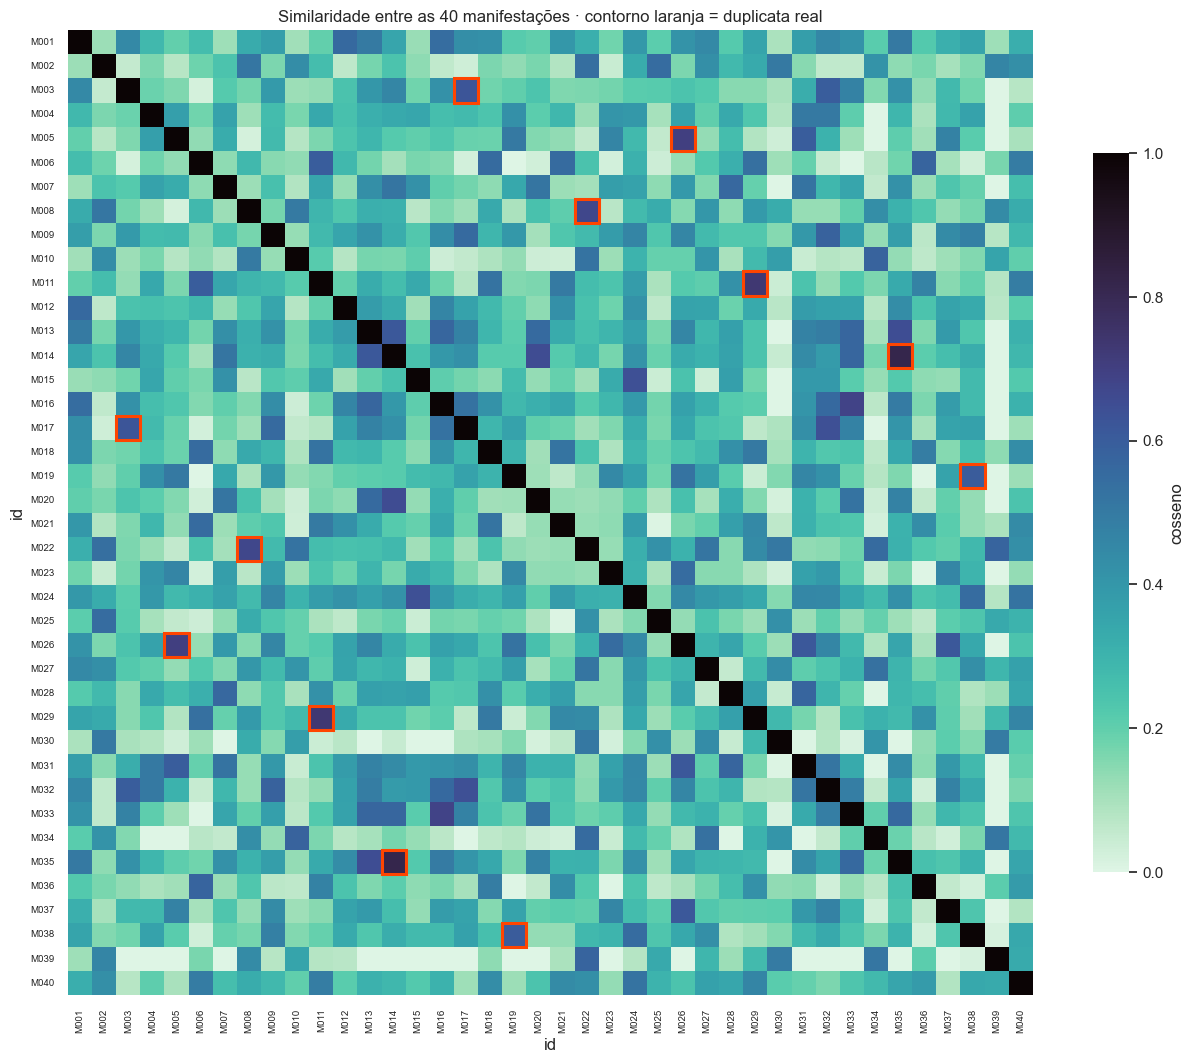

In [4]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(pd.DataFrame(S, index=base["id"], columns=base["id"]), cmap="mako_r", vmin=0, vmax=1, square=True,
            ax=ax, cbar_kws={"label": "cosseno", "shrink": .7}, xticklabels=True, yticklabels=True)
for a, b in gabarito:
    for r, c in [(pos[a], pos[b]), (pos[b], pos[a])]:
        ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="orangered", lw=2.2))
ax.tick_params(labelsize=7)
ax.set_title("Similaridade entre as 40 manifestações · contorno laranja = duplicata real")
plt.tight_layout(); plt.show()

### 3 · Qual limiar usar?
Duas evidências: a **distribuição** das similaridades (o enunciado sugere um limiar dinâmico por percentil) e uma **varredura** medindo precisão, recall e F1 contra o gabarito.

,valor
pares avaliados,780.000
duplicatas reais,6.000
percentil 90,0.473
percentil 95,0.536
percentil 99,0.643
menor cosseno entre duplicatas,0.602
maior cosseno entre não duplicatas,0.685


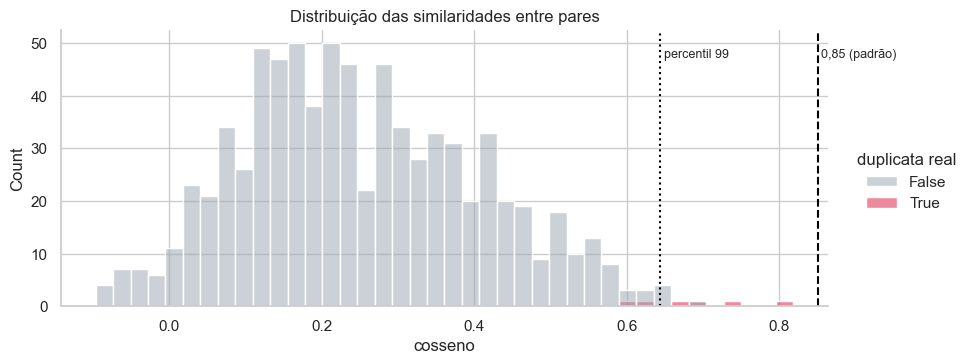

In [5]:
i, j = np.triu_indices(len(base), k=1)
pares = pd.DataFrame({"a": base["id"].to_numpy()[i], "b": base["id"].to_numpy()[j], "cosseno": S[i, j]})
pares["duplicata real"] = [tuple(sorted(p)) in gabarito for p in zip(pares.a, pares.b)]

resumo = {
    "pares avaliados": len(pares),
    "duplicatas reais": int(pares["duplicata real"].sum()),
    "percentil 90": np.percentile(pares.cosseno, 90),
    "percentil 95": np.percentile(pares.cosseno, 95),
    "percentil 99": np.percentile(pares.cosseno, 99),
    "menor cosseno entre duplicatas": pares.loc[pares["duplicata real"], "cosseno"].min(),
    "maior cosseno entre não duplicatas": pares.loc[~pares["duplicata real"], "cosseno"].max(),
}
display(pd.Series(resumo).to_frame("valor").style.format("{:.3f}"))

g = sns.displot(pares, x="cosseno", hue="duplicata real", bins=40, height=3.6, aspect=2.4,
                palette={False: "#9aa5b1", True: "crimson"}, multiple="layer")
for x, estilo, rot in [(0.85, "--", "0,85 (padrão)"), (np.percentile(pares.cosseno, 99), ":", "percentil 99")]:
    g.ax.axvline(x, ls=estilo, color="black"); g.ax.text(x + 0.005, g.ax.get_ylim()[1] * 0.9, rot, fontsize=9)
g.ax.set_title("Distribuição das similaridades entre pares"); plt.show()

In [6]:
def avaliar(limiar):
    previsto = pares.cosseno >= limiar
    vp = int((previsto & pares["duplicata real"]).sum())
    fp = int((previsto & ~pares["duplicata real"]).sum())
    fn = int((~previsto & pares["duplicata real"]).sum())
    precisao = vp / (vp + fp) if vp + fp else 0.0
    recall = vp / (vp + fn)
    f1 = 2 * precisao * recall / (precisao + recall) if precisao + recall else 0.0
    return {"limiar": limiar, "VP": vp, "FP": fp, "FN": fn, "precisão": precisao, "recall": recall, "F1": f1}

varredura = pd.DataFrame([avaliar(l) for l in np.round(np.arange(0.50, 0.96, 0.025), 3)])
escolhido = float(varredura.loc[varredura.F1.idxmax(), "limiar"])
print(f"Melhor F1 = {varredura.F1.max():.3f} no limiar {escolhido}")
varredura.style.format({"precisão": "{:.3f}", "recall": "{:.3f}", "F1": "{:.3f}"}).highlight_max("F1", color="#c8e6c9")

Melhor F1 = 0.667 no limiar 0.65


,limiar,VP,FP,FN,precisão,recall,F1
0,0.500000,6,59,0,0.092,1.000,0.169
1,0.525000,6,41,0,0.128,1.000,0.226
2,0.550000,6,29,0,0.171,1.000,0.293
3,0.575000,6,15,0,0.286,1.000,0.444
4,0.600000,6,10,0,0.375,1.000,0.545
5,0.625000,5,5,1,0.500,0.833,0.625
6,0.650000,4,2,2,0.667,0.667,0.667
7,0.675000,3,1,3,0.750,0.500,0.600
8,0.700000,2,0,4,1.000,0.333,0.500
9,0.725000,2,0,4,1.000,0.333,0.500


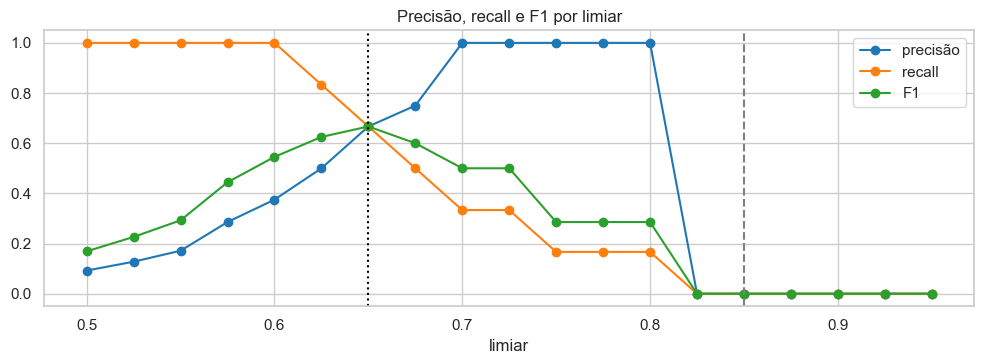

In [7]:
ax = varredura.plot(x="limiar", y=["precisão", "recall", "F1"], figsize=(10, 3.8), marker="o",
                   color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.axvline(0.85, ls="--", color="gray"); ax.axvline(escolhido, ls=":", color="black")
ax.set_title("Precisão, recall e F1 por limiar"); plt.tight_layout(); plt.show()

### 4 · Pares encontrados e erros, nos dois limiares

In [8]:
texto = dict(zip(base["id"], base["texto"]))

def classificar(limiar):
    achados = {tuple(sorted(p[:2])) for p in detectar_duplicatas(base["texto"], limiar, vetorizador, base["id"])}
    linhas = [(par, "VP" if par in gabarito else "FP") for par in achados]
    linhas += [(par, "FN") for par in gabarito - achados]
    return pd.DataFrame([{"limiar": limiar, "tipo": tipo, "par": f"{a} × {b}",
                          "cosseno": round(float(S[pos[a], pos[b]]), 3),
                          "texto A": texto[a][:95] + "…", "texto B": texto[b][:95] + "…"}
                         for (a, b), tipo in linhas]).sort_values(["tipo", "cosseno"], ascending=[True, False])

pd.concat([classificar(0.85), classificar(escolhido)], ignore_index=True)

,limiar,tipo,par,cosseno,texto A,texto B
0,0.85,FN,M014 × M035,0.818,"Há lixo acumulado no terreno baldio da Rua Goiás há meses. O mato está alto, tem rato e o mau c…",Terreno abandonado na Rua Goiás cheio de lixo e entulho. Aparecem ratos e baratas nas casas viz…
1,0.85,FN,M011 × M029,0.731,Os alunos da Escola Paulo Freire estão sem merenda escolar há uma semana. Muitas crianças só fa…,As crianças da Escola Paulo Freire não estão recebendo lanche há vários dias porque a merenda a…
2,0.85,FN,M005 × M026,0.700,A Rua Pernambuco está completamente escura à noite porque os postes de iluminação estão apagado…,"Poste sem luz na Rua Pernambuco. À noite a rua vira um breu e ninguém consegue ver nada, já ped…"
3,0.85,FN,M008 × M022,0.674,O posto de saúde do Jardim América está sem médico há duas semanas. As pessoas vão até lá e vol…,Falta atendimento no PSF do meu bairro. Não tem doutor para consultar e mandam a gente voltar o…
4,0.85,FN,M003 × M017,0.626,"Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estou…",O asfalto todo esburacado da avenida principal está causando acidentes. Precisa de recapeamento…
5,0.85,FN,M019 × M038,0.602,"Assaltos frequentes no ponto de ônibus da Avenida Norte, principalmente de manhã cedo quando ai…",Todo dia alguém é roubado na parada de ônibus da Av. Norte logo cedo. Precisamos de policiament…
6,0.65,FN,M003 × M017,0.626,"Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estou…",O asfalto todo esburacado da avenida principal está causando acidentes. Precisa de recapeamento…
7,0.65,FN,M019 × M038,0.602,"Assaltos frequentes no ponto de ônibus da Avenida Norte, principalmente de manhã cedo quando ai…",Todo dia alguém é roubado na parada de ônibus da Av. Norte logo cedo. Precisamos de policiament…
8,0.65,FP,M016 × M033,0.685,Moro na comunidade do Sítio Várzea e a única ligação com a cidade é uma ponte de madeira sobre …,Todas as semanas caminhões descarregam entulho de construção e restos de poda às margens do Rio…
9,0.65,FP,M014 × M020,0.655,"Há lixo acumulado no terreno baldio da Rua Goiás há meses. O mato está alto, tem rato e o mau c…",O córrego que passa atrás do Conjunto Habitacional Primavera está recebendo esgoto clandestino.…


## Justificativa do limiar e análise de erros

**O limiar padrão 0,85 não funciona nesta base.** Nenhum par chega a 0,85: a maior similaridade entre duplicatas reais é 0,818 (M014 × M035). Com 0,85 a função devolve lista vazia (0 VP e 6 FN). Isso acontece porque o modelo `paraphrase-multilingual-MiniLM-L12-v2` gera cossenos mais baixos para paráfrases que usam vocabulário muito diferente ("buraco enorme" × "asfalto todo esburacado").

**Limiar escolhido: 0,65.** Três evidências apontam para ele:
1. **Varredura contra o gabarito:** o F1 máximo (0,667) está em 0,65, com precisão e recall de 0,667 (4 VP, 2 FP, 2 FN).
2. **Limiar dinâmico por percentil:** o percentil 99 da distribuição dos 780 pares é 0,643, praticamente o mesmo valor. Isso importa porque, em produção, não existe gabarito, e o percentil pode ser recalculado a cada lote de manifestações.
3. **Distribuição:** o histograma mostra que as duplicatas ficam na cauda direita (0,60 a 0,82), enquanto a massa de pares não duplicados está abaixo de 0,55.

Trade-off: 0,60 encontra as 6 duplicatas (recall 1,0) com 10 falsos positivos; 0,70 tem precisão 1,0 mas só acha 2. Para uma ouvidoria, **perder uma duplicata custa pouco** (a manifestação só é tratada em separado), enquanto **fundir manifestações diferentes** pode fazer um problema real ser ignorado. Por isso, o sistema deve **sugerir** os pares acima de 0,65 para um atendente confirmar, e não fundi-los automaticamente.

**Falsos positivos (limiar 0,65):**
- **M016 × M033 (0,686):** ponte de madeira no Sítio Várzea × entulho no Rio Jaguaribe. São os dois textos longos que falam de rio/riacho, ponte, cheia e comunidade isolada. O vocabulário do cenário é parecido, mas os problemas são diferentes (infraestrutura × descarte irregular). Textos longos misturam vários assuntos num único vetor, e é esse o motivo da Entrega 3 (chunking).
- **M014 × M020 (0,655):** lixo no terreno baldio × esgoto no córrego. Mesmo tema (meio ambiente/saneamento, mau cheiro), mas locais e problemas diferentes. É um erro "vizinho": agrupar os dois num mesmo cluster seria correto, marcar como duplicata não.

**Falsos negativos:**
- **M003 × M017 (0,626):** a M003 cita um local específico (Av. Brasil, supermercado) e um efeito (pneu estourado); a M017 fala de "avenida principal", recapeamento e acidentes. O modelo não sabe que a "avenida principal" é a Av. Brasil. Só um humano ou a geolocalização da manifestação resolveria.
- **M019 × M038 (0,602):** "assaltos frequentes no ponto de ônibus" × "alguém é roubado na parada de ônibus". Sinônimos regionais (ponto × parada) e a mudança de voz ("assaltos" × "é roubado") reduzem a similaridade.

**Melhorias possíveis:** comparar também os nomes de logradouros extraídos (busca léxica), usar um modelo maior (ex.: `BAAI/bge-m3`) ou reranquear os candidatos com um cross-encoder.